In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('IRIS.csv')
df.head()

 

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
X = df.drop('species',axis=1)

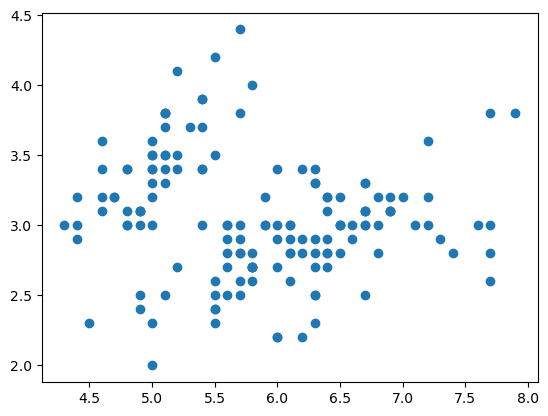

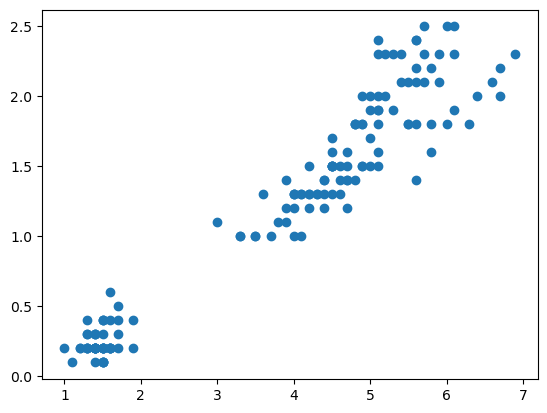

In [3]:
plt.scatter(X.sepal_length,X.sepal_width)
plt.show()
plt.scatter(X.petal_length,X.petal_width)
plt.show()

In [4]:
from sklearn.cluster import KMeans

k = KMeans(n_clusters=2)
k.fit(X)
print(k.labels_)



[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


C:\Users\Rudra Pratap Singh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [5]:
print(k.inertia_)

152.36870647733906


In [6]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


C:\Users\Rudra Pratap Singh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Rudra Pratap Singh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Rudra Pratap Singh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Rudra Pratap Singh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

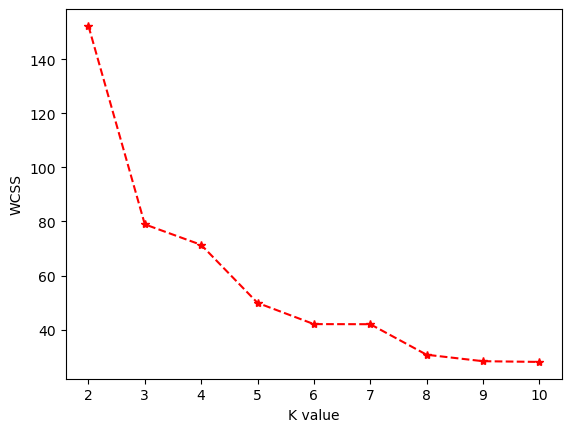

In [7]:
WCSS=[]
for k in range(2,11):
    KM = KMeans(n_clusters=k)
    KM.fit(X)
    WCSS.append(KM.inertia_)
plt.plot(range(2,11),WCSS,'*--r')
plt.xlabel("K value")
plt.ylabel("WCSS")
plt.show()

C:\Users\Rudra Pratap Singh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Rudra Pratap Singh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Rudra Pratap Singh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Rudra Pratap Singh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

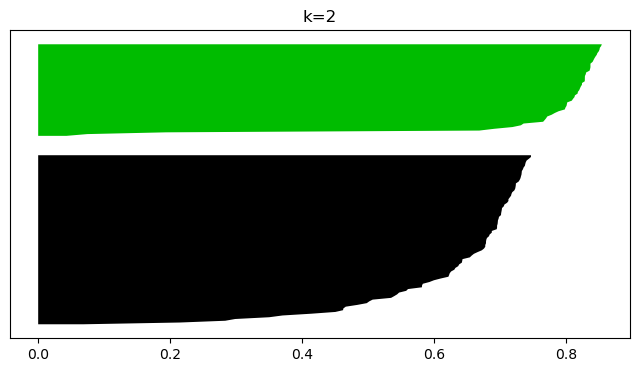

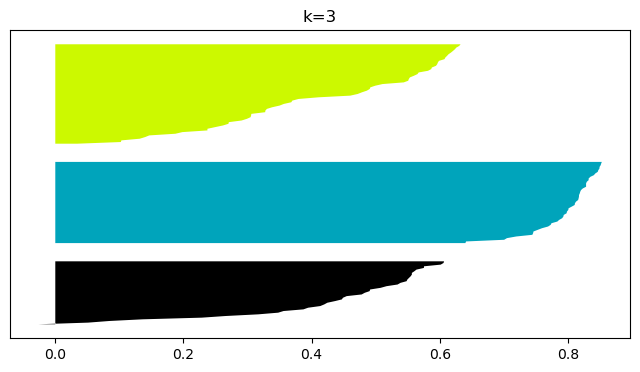

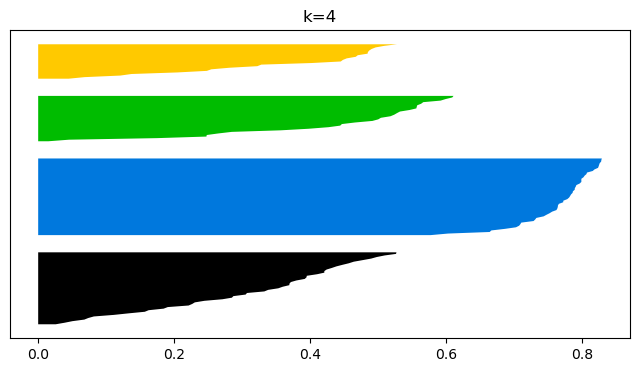

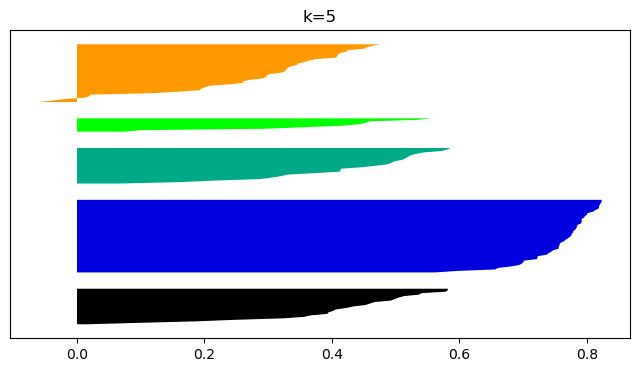

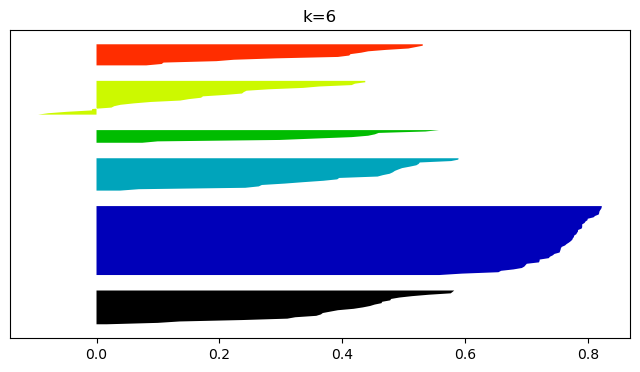

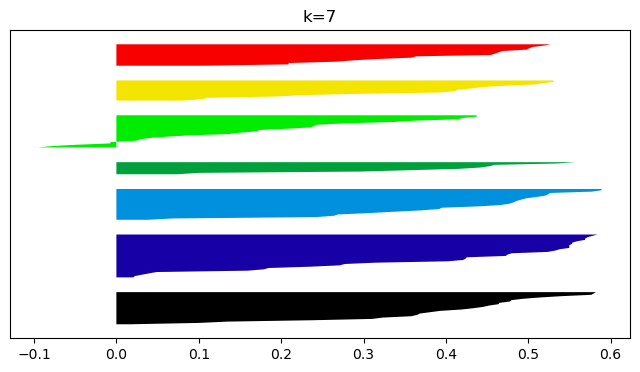

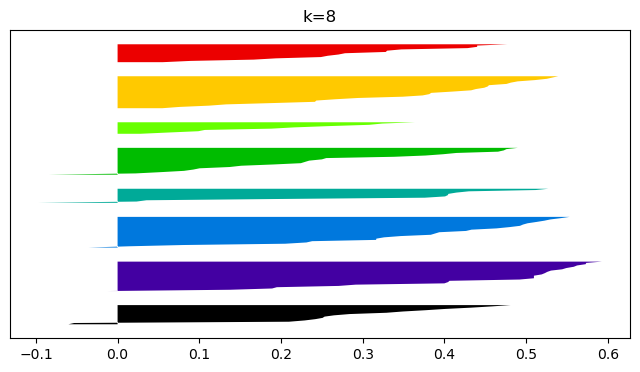

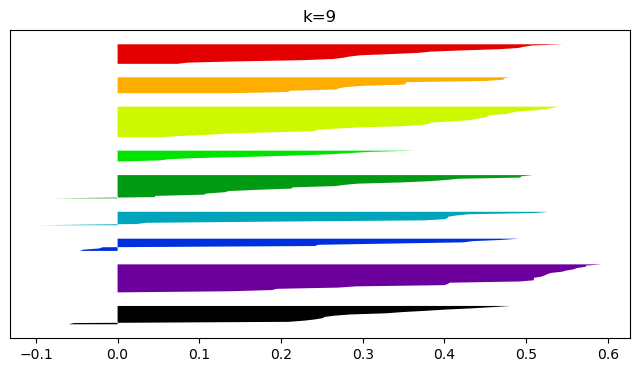

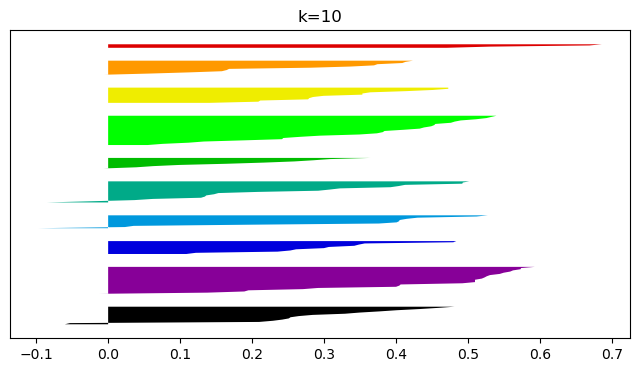

In [8]:
from sklearn.metrics import silhouette_samples,silhouette_score
import matplotlib.cm as cm
for k in range(2,11):
    fig,ax =plt.subplots(figsize=(8,4))
    cluster_labels=KMeans(n_clusters=k,random_state=10).fit_predict(X)
    sample_silhouette_values = silhouette_samples(X,cluster_labels)
    y_lower =10
    for i in range(k):
        values = np.sort(sample_silhouette_values[cluster_labels==i])
        y_upper=y_lower+len(values)
        color = cm.nipy_spectral(float(i)/k)
        ax.fill_betweenx(np.arange(y_lower,y_upper),0,values,facecolor=color)
        y_lower=10+y_upper
    ax.set_title(f"k={k}")
    ax.set_yticks([])
plt.show()
        

AttributeError: module 'pandas' has no attribute 'ndim'